# Eniac A/B Test: Finding the Best Call-to-Action Button

**Case:** Eniac homepage CTA button experiment  
**Methods:** Chi-Square test of independence, Bonferroni-corrected pairwise post-hoc tests, relative-lift analysis.

This notebook documents the statistical analysis of an A/B/C/D test run on the Eniac landing page. Four variants of the primary call-to-action button were served to randomly assigned visitors. The goal is to identify the variant that maximizes click-through rate (CTR) while respecting statistical rigor.

## 1. Context

Eniac is an online electronics retailer. The marketing team hypothesized that the current CTA button on the homepage is underperforming and designed four candidate variants crossing two design dimensions:

| Version | Color | Label       |
|:-------:|:-----:|:------------|
| A       | White | SHOP NOW    |
| B       | Red   | SHOP NOW    |
| C       | White | SEE DEALS   |
| D       | Red   | SEE DEALS   |

Each visitor is randomly assigned to exactly one variant. We record the number of unique visitors and the number of CTA clicks per variant.

## 2. Data Preparation

We load the four CSV files — one per variant — and extract the number of clicks on the primary CTA button of each page.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

pd.set_option("display.max_colwidth", None)

In [2]:
# Auto-detect environment: load locally if available, otherwise from Google Drive (Colab).
import os

LOCAL_DATA_DIR = "../data"

drive_urls = {
    "a": "https://drive.google.com/file/d/1xRt51ZBlphdM7NGk2EWOjU4NEN_cF3ZY/view?usp=sharing",
    "b": "https://drive.google.com/file/d/12MwefDNwyyHWVzAlLSMCdTsIHpRxo9vL/view?usp=sharing",
    "c": "https://drive.google.com/file/d/1MegFyfDaVtF9z8-EBXe9Pr66UPaepTgM/view?usp=sharing",
    "d": "https://drive.google.com/file/d/1BIX3g7MPbMV7mKqSikPcHxw13ahfjx8o/view?usp=sharing",
}

def gdrive_direct(share_url: str) -> str:
    file_id = share_url.split("/")[-2]
    return f"https://drive.google.com/uc?export=download&id={file_id}"

if os.path.isdir(LOCAL_DATA_DIR):
    sources = {k: f"{LOCAL_DATA_DIR}/eniac_{k}.csv" for k in "abcd"}
else:
    sources = {k: gdrive_direct(v) for k, v in drive_urls.items()}

eniac_a = pd.read_csv(sources["a"])
eniac_b = pd.read_csv(sources["b"])
eniac_c = pd.read_csv(sources["c"])
eniac_d = pd.read_csv(sources["d"])

eniac_a.head()

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • https://eniac.com/index-a.php
1,25,div,mySidebar,309,True,"created 2021-09-14 • 14 days 0 hours 34 mins • 25326 visits, 23174 clicks"
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN


### 2.1 Extract clicks and visits

For variants A and B the primary CTA is labelled `SHOP NOW`; for variants C and D it is labelled `SEE DEALS`. Visitor counts were read from the snapshot row (element ID 25) of each export.

In [3]:
clicks_a = eniac_a.loc[eniac_a["Name"] == "SHOP NOW", "No. clicks"].values[0]
clicks_b = eniac_b.loc[eniac_b["Name"] == "SHOP NOW", "No. clicks"].values[0]
clicks_c = eniac_c.loc[eniac_c["Name"] == "SEE DEALS", "No. clicks"].values[0]
clicks_d = eniac_d.loc[eniac_d["Name"] == "SEE DEALS", "No. clicks"].values[0]

visits = {"A": 25326, "B": 24747, "C": 24876, "D": 25233}

contingency_table = [
    [clicks_a, visits["A"] - clicks_a],
    [clicks_b, visits["B"] - clicks_b],
    [clicks_c, visits["C"] - clicks_c],
    [clicks_d, visits["D"] - clicks_d],
]
contingency_table

[[np.int64(512), np.int64(24814)],
 [np.int64(281), np.int64(24466)],
 [np.int64(527), np.int64(24349)],
 [np.int64(193), np.int64(25040)]]

### 2.2 Click-Through Rates

The CTR is the share of visitors who clicked the CTA.

In [4]:
ctr_a = clicks_a / visits["A"]
ctr_b = clicks_b / visits["B"]
ctr_c = clicks_c / visits["C"]
ctr_d = clicks_d / visits["D"]

ctr_summary = pd.DataFrame(
    {
        "Version": ["A", "B", "C", "D"],
        "Color": ["White", "Red", "White", "Red"],
        "Label": ["SHOP NOW", "SHOP NOW", "SEE DEALS", "SEE DEALS"],
        "Visits": list(visits.values()),
        "Clicks": [clicks_a, clicks_b, clicks_c, clicks_d],
        "CTR (%)": [round(ctr * 100, 2) for ctr in (ctr_a, ctr_b, ctr_c, ctr_d)],
    }
)
ctr_summary

,Version,Color,Label,Visits,Clicks,CTR (%)
0,A,White,SHOP NOW,25326,512,2.02
1,B,Red,SHOP NOW,24747,281,1.14
2,C,White,SEE DEALS,24876,527,2.12
3,D,Red,SEE DEALS,25233,193,0.76


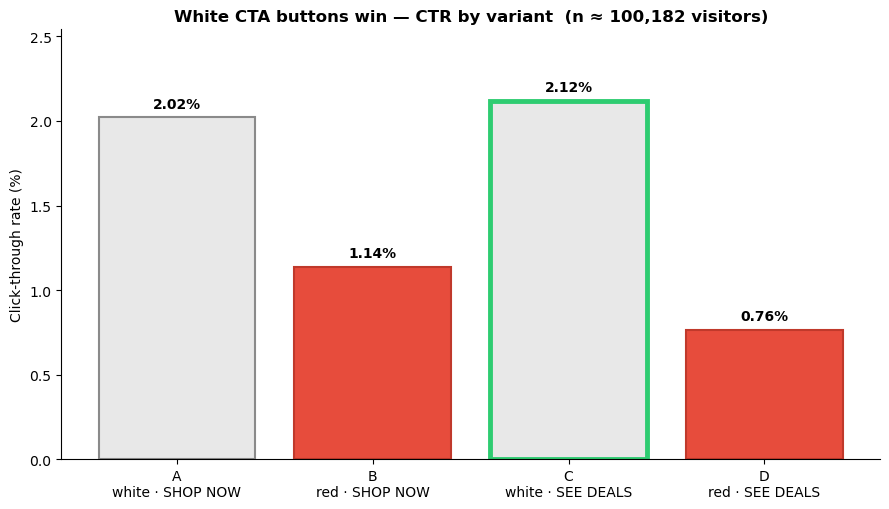

In [5]:
# Click-through rate by variant — the decisive result, coloured by button colour.
# White buttons (A, C) share a light fill; red buttons (B, D) are red. The
# recommended rollout, C, gets a green outline. This visualises the core finding:
# colour drives CTR far more than the label does.
labels = ["A\nwhite · SHOP NOW", "B\nred · SHOP NOW",
          "C\nwhite · SEE DEALS", "D\nred · SEE DEALS"]
ctrs = [ctr_a * 100, ctr_b * 100, ctr_c * 100, ctr_d * 100]
fills = ["#e8e8e8", "#e74c3c", "#e8e8e8", "#e74c3c"]
edges = ["#8a8a8a", "#c0392b", "#2ecc71", "#c0392b"]
lws = [1.5, 1.5, 3.5, 1.5]

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(labels, ctrs, color=fills, edgecolor=edges, linewidth=lws)
for bar, ctr in zip(bars, ctrs):
    ax.text(bar.get_x() + bar.get_width() / 2, ctr + 0.04,
            f"{ctr:.2f}%", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Click-through rate (%)")
ax.set_title("White CTA buttons win — CTR by variant  (n ≈ 100,182 visitors)",
             fontweight="bold")
ax.set_ylim(0, max(ctrs) * 1.2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("../images/ctr_by_variant.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Hypothesis Testing

### 3.1 Hypotheses

- **H0 (Null):** All four versions share the same true CTR.
- **H1 (Alternative):** At least one version has a different true CTR.

### 3.2 Significance level

A relatively permissive significance level of `alpha = 0.10` was agreed with the business. The business accepts a 10% probability of a type-I error in exchange for higher statistical power.

In [6]:
alpha = 0.10

### 3.3 Global Chi-Square test

We run a Pearson chi-square test of independence on the 4×2 contingency table (clicks vs. non-clicks by version).

In [7]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square statistic: {chi2:.4f}")
print(f"P-value:              {p_value:.4e}")
print(f"Degrees of freedom:   {dof}")
print("Expected frequencies (rounded):")
print(expected.round(2))

Chi-Square statistic: 224.0188
P-value:              2.7161e-48
Degrees of freedom:   3
Expected frequencies (rounded):
[[  382.49 24943.51]
 [  373.74 24373.26]
 [  375.69 24500.31]
 [  381.08 24851.92]]


**Interpretation.** The p-value is far below our alpha, so we reject H0. The four variants do **not** share the same CTR — at least one button performs differently from the others. The global test alone, however, does not tell us *which* variant wins. That requires a post-hoc analysis.

## 4. Post-hoc Analysis (Pairwise Chi-Square with Bonferroni Correction)

With four variants we have `C(4, 2) = 6` pairwise comparisons. Running six independent tests at `alpha = 0.10` inflates the family-wise error rate well above 10%. We apply the Bonferroni correction:

$$\alpha_{adj} = \frac{\alpha}{k} = \frac{0.10}{6} \approx 0.0167$$

In [8]:
versions = ["A", "B", "C", "D"]
num_comparisons = 6
alpha_bonf = alpha / num_comparisons

print(f"Bonferroni-adjusted alpha: {alpha_bonf:.4f}\n")

for i, j in combinations(range(4), 2):
    pair_table = [contingency_table[i], contingency_table[j]]
    _, p_pair, _, _ = stats.chi2_contingency(pair_table)
    verdict = "SIGNIFICANT" if p_pair < alpha_bonf else "not significant"
    print(f"{versions[i]} vs {versions[j]}: p = {p_pair:.4e} -> {verdict}")

Bonferroni-adjusted alpha: 0.0167

A vs B: p = 2.6731e-15 -> SIGNIFICANT
A vs C: p = 4.6484e-01 -> not significant
A vs D: p = 3.0809e-33 -> SIGNIFICANT
B vs C: p = 6.9555e-18 -> SIGNIFICANT
B vs D: p = 2.3573e-05 -> SIGNIFICANT
C vs D: p = 6.4505e-37 -> SIGNIFICANT


**Findings.**

- Both white buttons (A, C) significantly outperform both red buttons (B, D).
- The difference between the two white buttons (A vs. C) is **not** statistically significant — we cannot claim that `SEE DEALS` beats `SHOP NOW` on CTR alone.
- **Color is the dominant driver** of CTR; the label is a secondary effect.

## 5. Business Perspective: Relative Lift

Statistical significance answers "is the difference real?" but not "is it worth it?". The relative lift translates the CTR gap into a business-friendly percentage improvement over the current baseline (A).

In [9]:
lift_c_vs_a = (ctr_c - ctr_a) / ctr_a * 100
print(f"Relative lift of Version C over Version A: {lift_c_vs_a:.2f}%")

Relative lift of Version C over Version A: 4.79%


Version C delivers a ~5% relative lift in CTR over the current baseline A. Although this gap is not statistically significant on its own, it is directionally positive and economically meaningful at Eniac's traffic scale.

## 6. Supplementary Metrics: Drop-off and Return Rate

Two further metrics were reported in the LMS dashboards (no CSV export available). They describe what happens *after* the landing page loads, so they complement — but do not override — the CTR analysis above.

- **Drop-off rate** — share of users who leave the landing page without continuing. *Lower is better.*
- **Homepage-return rate** — share of users who return to the homepage after clicking the CTA; a proxy for a click that did not match user expectations. *Lower is better.*

The numbers tell a more nuanced story than the CTR alone:

- **Version A** has the **lowest drop-off rate (~62%)** but the **highest return rate (~5.3%)** — more people stay on the landing page, yet those who click come back more often, suggesting the `SHOP NOW` label over-promises.
- **Version D** has the **lowest return rate (~2.6%)** — fewest post-click regrets — but still a high drop-off (~69.5%) and by far the weakest CTR.
- **Version C** sits in between on both: drop-off ~71.5%, return rate ~4.7%. It loses more users to the landing page than A, but keeps post-click users engaged better than A.
- **Version B** is missing from both dashboards due to a tracking error during the test window.

These metrics are directional only — the LMS dashboards report point values without confidence intervals — so they support the CTR analysis rather than replace it.

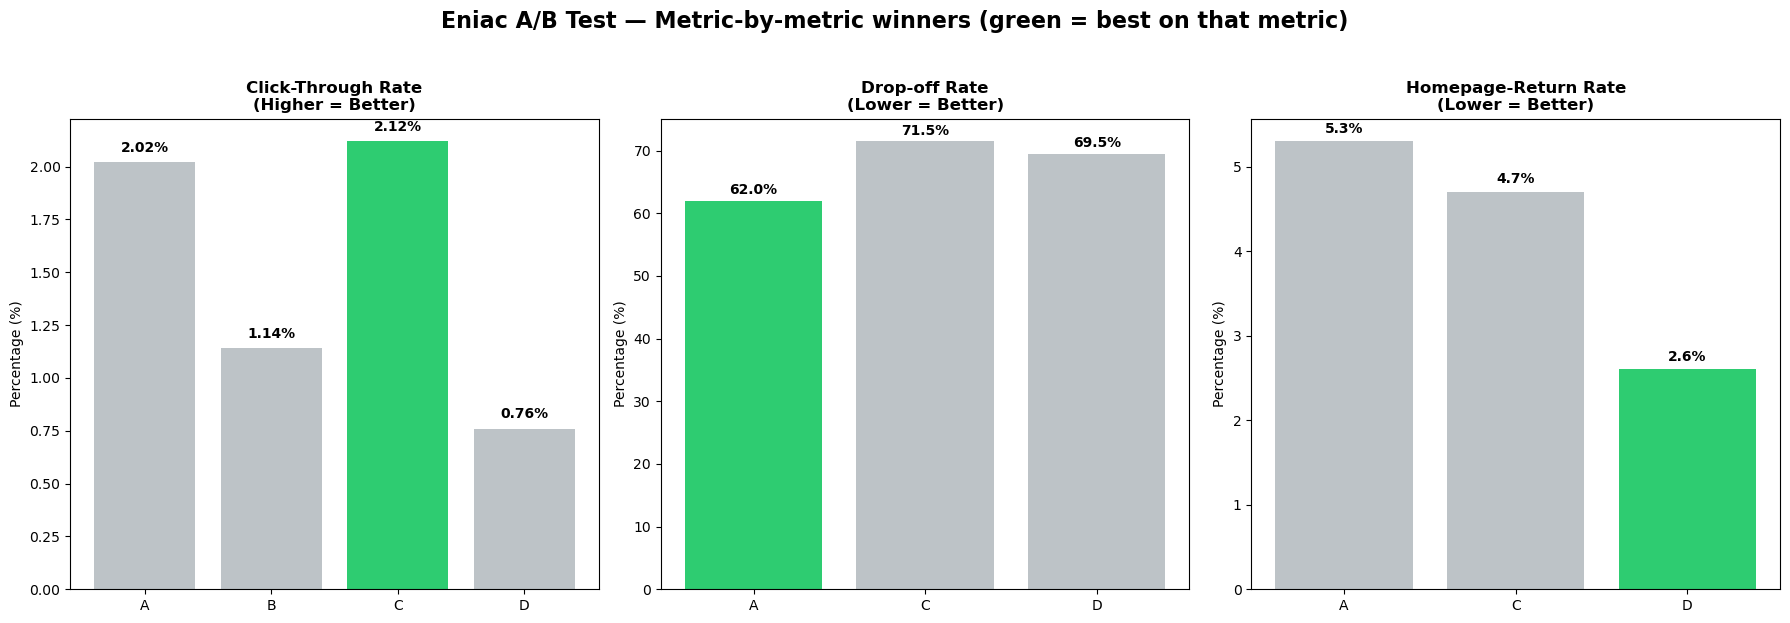

In [10]:
supplementary = {
    "Version": ["A", "B", "C", "D"],
    "CTR": [2.02, 1.14, 2.12, 0.76],
    "Drop_off": [62.0, np.nan, 71.5, 69.5],
    "Return_rate": [5.3, np.nan, 4.7, 2.6],
}
metrics_df = pd.DataFrame(supplementary)

plt.style.use("seaborn-v0_8-muted")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

highlight_color = "#2ecc71"   # best-in-metric winner
others_color    = "#bdc3c7"

def highlight_palette(values_series, mode):
    """Colour the bar with the best value in `mode` ('max' or 'min')."""
    valid = values_series.dropna()
    best = valid.max() if mode == "max" else valid.min()
    return [
        highlight_color if (not pd.isna(v) and v == best) else others_color
        for v in values_series
    ]

# CTR — higher is better -> highlight the maximum (Version C)
axes[0].bar(
    metrics_df["Version"],
    metrics_df["CTR"],
    color=highlight_palette(metrics_df["CTR"], mode="max"),
)
axes[0].set_title("Click-Through Rate\n(Higher = Better)", fontweight="bold")
axes[0].set_ylabel("Percentage (%)")
for i, value in enumerate(metrics_df["CTR"]):
    axes[0].text(i, value + 0.05, f"{value}%", ha="center", fontweight="bold")

# Drop-off — lower is better -> highlight the minimum (Version A)
drop_df = metrics_df.dropna(subset=["Drop_off"]).reset_index(drop=True)
axes[1].bar(
    drop_df["Version"],
    drop_df["Drop_off"],
    color=highlight_palette(drop_df["Drop_off"], mode="min"),
)
axes[1].set_title("Drop-off Rate\n(Lower = Better)", fontweight="bold")
axes[1].set_ylabel("Percentage (%)")
for i, value in enumerate(drop_df["Drop_off"]):
    axes[1].text(i, value + 1, f"{value}%", ha="center", fontweight="bold")

# Homepage-Return — lower is better -> highlight the minimum (Version D)
ret_df = metrics_df.dropna(subset=["Return_rate"]).reset_index(drop=True)
axes[2].bar(
    ret_df["Version"],
    ret_df["Return_rate"],
    color=highlight_palette(ret_df["Return_rate"], mode="min"),
)
axes[2].set_title("Homepage-Return Rate\n(Lower = Better)", fontweight="bold")
axes[2].set_ylabel("Percentage (%)")
for i, value in enumerate(ret_df["Return_rate"]):
    axes[2].text(i, value + 0.1, f"{value}%", ha="center", fontweight="bold")

plt.suptitle(
    "Eniac A/B Test — Metric-by-metric winners (green = best on that metric)",
    fontsize=16,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()

## 7. Business Recommendation

**Recommendation: Roll out Version C — the white `SEE DEALS` button.**

1. **Statistical evidence on CTR.** The global chi-square test rejects the null at `alpha = 0.10`. Pairwise Bonferroni-corrected tests show that both white buttons (A, C) significantly beat both red buttons (B, D). Color is the dominant, statistically proven driver.
2. **CTR direction within the white pair.** Among the white buttons, C has the highest observed CTR (2.12%) and a ~5% relative lift over the current baseline A. The A-vs-C gap is not statistically significant, so picking C over A is a judgment call on directional evidence — not a forced conclusion.
3. **Supplementary metrics — a trade-off, not a clean win.** The LMS drop-off and return-rate dashboards paint a more nuanced picture:
    - Version **A** has the lowest drop-off rate (~62% vs. C's ~71.5%) — more users stay on the landing page.
    - Version **D** has the lowest return rate (~2.6% vs. C's ~4.7%) — fewest post-click regrets.
    - Version **C** sits in between on both. Its `SEE DEALS` label keeps post-click users engaged better than A's `SHOP NOW` (lower return rate), at the cost of more users dropping off the landing page before they click.
4. **Why C is still the defensible choice.** The supplementary metrics come from dashboards without confidence intervals, and Version B is missing from both — they are directional, not definitive. On the only metric we can test rigorously (CTR), C delivers the largest observed lift over the status-quo baseline A with no statistically worse downside. Given that color is the dominant significant driver and A/C are statistically tied on CTR, C is defensible as the rollout choice on the strength of the headline metric.

**Next steps.** Because the supplementary metrics do not all point the same direction, a confirmatory A/B test comparing **A vs. C head-to-head** is recommended before a full rollout. Instrument that test to capture the entire funnel — landing → click → purchase → homepage return — so the drop-off / return-rate trade-off can be resolved on measured revenue rather than on directional dashboards.